# Modelica Pendulum: Discrete Contact

This tutorial extends the basic pendulum model to a **discrete wall-contact** case and analyzes state-event behavior after FMU export.

The main objective is to show a practical co-simulation fact: for FMUs that contain Modelica state events, the detected event instant at the master level is sensitive to the macro communication step size `dt`.


## Overview

We will:

1. Define a Modelica pendulum with discrete impact (`when` + `reinit`).
2. Compute a direct Modelica reference trajectory (`dassl`).
3. Export FMI 2.0 co-simulation FMUs (`cvode`, `euler`).
4. Run FMUs in `syssimx` with different macro step sizes.
5. Compare first-contact timing and penetration indicators.

This isolates macro-step sensitivity before introducing hybrid rollback algorithms.


## Learning Goals

- Understand how Modelica expresses impact events through equation-level state events.
- Understand why FMU co-simulation exposes event timing only at communication boundaries.
- Quantify how reducing macro step size improves observed event-time accuracy.
- Prepare the foundation for the next tutorials on rollback-based event localization and explicit event handling in `syssimx`.


## Prerequisites and Setup

We assume the setup from tutorial 01 is available:

- OpenModelica + `OMPython`
- `syssimx` Python environment
- plotting stack (`numpy`, `matplotlib`)

The model used here is `PendulumDiscreteContact.mo`.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from syssimx import FMUComponent

## Theory: Discrete Contact in Modelica (Compact)

For the pendulum state

$$
\dot{\theta}=\omega, \qquad
\dot{\omega}=-(m g L/I)\sin(\theta) + \tau/I,
$$

a rigid wall at `theta_wall` is represented as a **state event**:

- event condition: `theta <= theta_wall`
- event action: `reinit(omega, -omega)` (ideal elastic velocity inversion)

In direct Modelica simulation, variable-step solvers (e.g., `dassl`) localize event times internally with root-finding.

In FMI 2.0 co-simulation, the master advances the FMU by macro steps (`do_step(t, dt)`), and outputs are observed at communication points. Therefore, coarse `dt` can delay detected event instant, while smaller `dt` generally increases temporal accuracy at higher computational cost.


## Modelica Implementation

The model below contains:

- continuous pendulum dynamics (`theta`, `omega`)
- discrete impact handling with `when`/`reinit`
- a Boolean `contact` output for diagnostics

This `contact` signal is useful to compare event observability between direct Modelica simulation and FMU co-simulation.


```Modelica
model PendulumDiscreteContact  
  // Imports
  import Modelica.Constants.pi;

  // Parameters
  parameter Real m(unit="kg") = 40;
  parameter Real L(unit="m") = 0.6;
  parameter Real theta0(unit="rad") = 0;
  parameter Real omega0(unit="rad/s") = 0;
  parameter Real g(unit="m/s2") = 9.81;
  parameter Real inertia(unit="kg.m2") = 20;
  parameter Real theta_wall (unit="rad") = 0;
  parameter Integer sense = -1; 

  // Input torque at the pivot
  Modelica.Blocks.Interfaces.RealInput torque(unit="N.m");

  // Outputs
  Modelica.Blocks.Interfaces.RealOutput theta(unit="rad");
  Modelica.Blocks.Interfaces.RealOutput omega(unit="rad/s");
  Modelica.Blocks.Interfaces.RealOutput alpha(unit="rad/s2") = der(omega);
  Modelica.Blocks.Interfaces.BooleanOutput contact;

initial equation
  theta = theta0;
  omega = omega0;
  contact = theta <= theta_wall and omega < 0;

equation
  der(theta) = omega;
  der(omega) = -(m * g * L / inertia) * sin(theta) + torque / inertia;
  
  when theta <= theta_wall then
    contact = true;
    reinit(omega, -omega);  
  elsewhen theta >= theta_wall then
    contact = false;
  end when;
  
end PendulumDiscreteContact;

In [2]:
model_file = Path("docs/tutorials/tool_integration/modelica/PendulumDiscreteContact.mo")

## Simulate `ModelicaSystem`

We first run the model directly in OpenModelica (`dassl`) as a reference trajectory.

This reference is used to assess how well FMU co-simulation reproduces event timing and minimum angle near impact.


In [3]:
modelica_pendulum = ModelicaSystem(
    fileName=str(model_file),
    modelName="PendulumDiscreteContact",
)
modelica_pendulum.buildModel()


# Initial condition chosen to trigger repeated wall impacts
theta0 = 0.5
omega0 = 0.0
modelica_pendulum.setParameters({"theta0": str(theta0), "omega0": str(omega0)})

True

In [4]:
t_stop = 2.0
dt_ref = 1e-4
tol_ref = 1e-8

simulation_arguments = {
    "startTime": 0.0,
    "stopTime": t_stop,
    "stepSize": dt_ref,
    "tolerance": tol_ref
}

modelica_pendulum.simulate(simargs=simulation_arguments)

t_ref, theta_ref, omega_ref, contact_ref = modelica_pendulum.getSolutions(
    ["time", "theta", "omega", "contact"]
)

t_ref = np.asarray(t_ref).squeeze()
theta_ref = np.asarray(theta_ref).squeeze()
omega_ref = np.asarray(omega_ref).squeeze()
contact_ref = np.asarray(contact_ref).squeeze().astype(bool)

theta_wall = 0.0

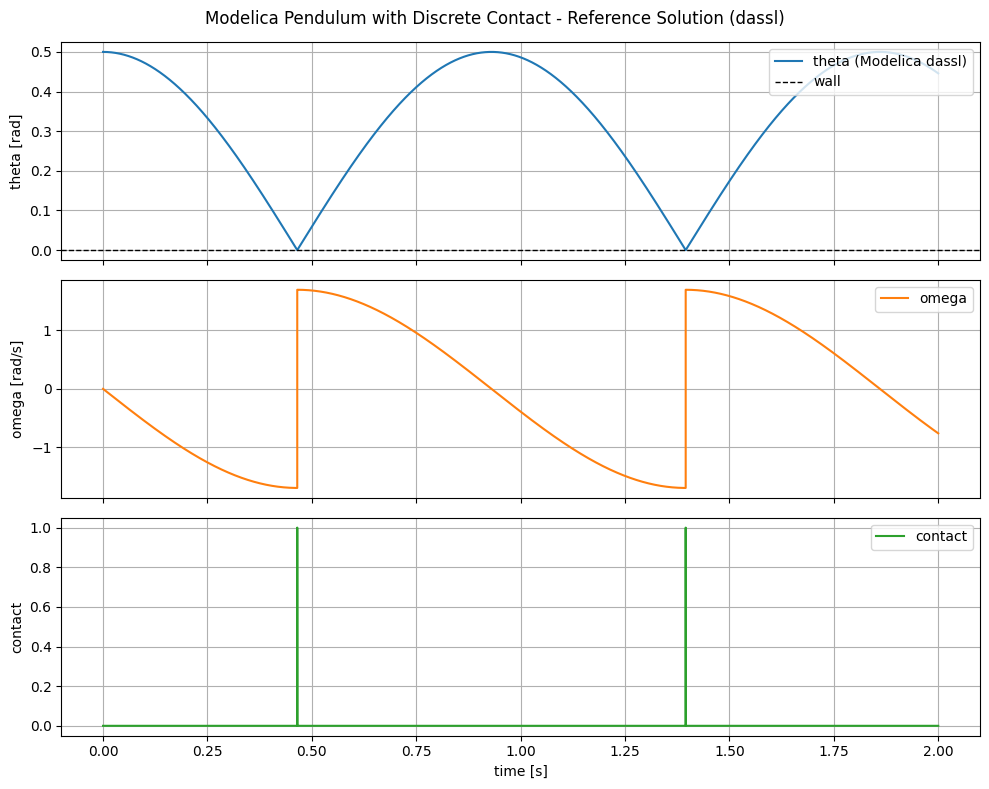

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Modelica Pendulum with Discrete Contact - Reference Solution (dassl)")
axs[0].plot(t_ref, theta_ref, label="theta (Modelica dassl)")
axs[0].axhline(theta_wall, color="k", linestyle="--", linewidth=1, label="wall")
axs[0].set_ylabel("theta [rad]")
axs[0].grid(True)
axs[0].legend(loc="upper right")

axs[1].plot(t_ref, omega_ref, color="tab:orange", label="omega")
axs[1].set_ylabel("omega [rad/s]")
axs[1].grid(True)
axs[1].legend(loc="upper right")

axs[2].step(t_ref, contact_ref.astype(int), where="post", color="tab:green", label="contact")
axs[2].set_ylabel("contact")
axs[2].set_xlabel("time [s]")
axs[2].grid(True)
axs[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Export to FMU

We export two FMI 2.0 Co-Simulation FMUs from the same Modelica model:

- `cvode`
- `euler`

This keeps the physical model fixed while changing only the FMU solver/integration behavior.


In [6]:
modelica_cvode = ModelicaSystem(
    fileName=str(model_file),
    modelName="PendulumDiscreteContact",
    commandLineOptions=["--fmiFlags=s:cvode"],
)
modelica_cvode.buildModel()

modelica_euler = ModelicaSystem(
    fileName=str(model_file),
    modelName="PendulumDiscreteContact",
    commandLineOptions=["--fmiFlags=s:euler"],
)
modelica_euler.buildModel()

fmu_path_cvode = modelica_cvode.convertMo2Fmu(version="2.0", fmuType="cs")
fmu_path_euler = modelica_euler.convertMo2Fmu(version="2.0", fmuType="cs")

fmu_components = {
    "cvode": FMUComponent(name="PendulumCVODE", fmu_path=fmu_path_cvode),
    "euler": FMUComponent(name="PendulumEuler", fmu_path=fmu_path_euler),
}

[OMC log for 'sendExpression(buildModelFMU(PendulumDiscreteContact, version="2.0", fmuType="cs", fileNamePrefix="PendulumDiscreteContact", includeResources=true), True)']: [symbolic:warning:592] Variable omega has attribute stateSelect=StateSelect.always, but can't be selected as a state.
[OMC log for 'sendExpression(buildModelFMU(PendulumDiscreteContact, version="2.0", fmuType="cs", fileNamePrefix="PendulumDiscreteContact", includeResources=true), True)']: [symbolic:warning:592] Variable omega has attribute stateSelect=StateSelect.always, but can't be selected as a state.


## FMU Simulation

Each FMU is simulated in `syssimx` with two macro communication step sizes (`dt=0.01` and `dt=0.001`).

This experiment demonstrates the key effect of this tutorial:

- larger macro `dt`: lower event-time observability accuracy
- smaller macro `dt`: better event detection accuracy, but more computational effort

The observed trend motivates the next tutorials, where event localization is improved with rollback and explicit hybrid event handling.


In [8]:
fmu_components = {
    "cvode": FMUComponent(name="PendulumCVODE", fmu_path=fmu_path_cvode),
    "euler": FMUComponent(name="PendulumEuler", fmu_path=fmu_path_euler),
}

dt_values = [1e-2, 1e-3, 1e-4]

fmu_results = {}

for solver_name, comp in fmu_components.items():
    fmu_results[solver_name] = {}
    for dt in dt_values:
        dt_results = {}
        comp.reset()
        comp.set_parameters(theta0=theta0, omega0=omega0)
        comp.initialize(t0=0.0)
        t_vals = np.arange(0.0, t_stop + dt, dt)
        for t in t_vals:
            comp.do_step(t, dt)
        history = comp.get_history()
        dt_results['theta'] = history['theta']
        dt_results['omega'] = history['omega']
        dt_results['contact'] = history['contact']
        fmu_results[solver_name][f"{dt}"] = dt_results

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

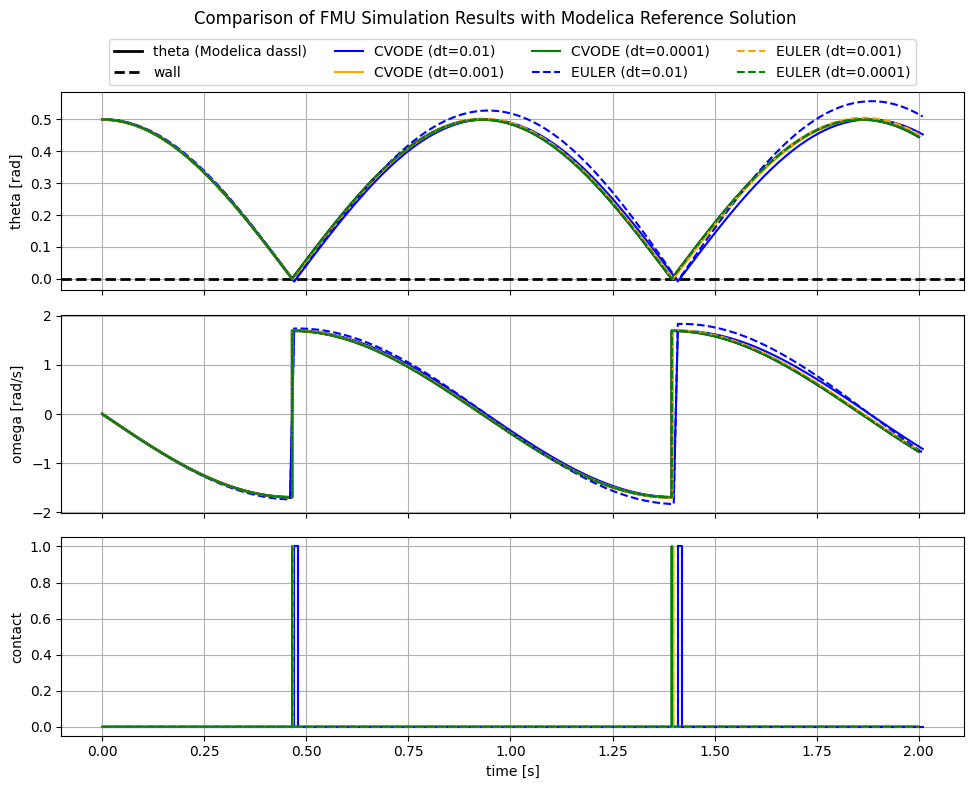

In [9]:
linestyles = {"euler": "dashed", "cvode": "solid"}
colors = {1e-2: "blue", 1e-3: "orange", 1e-4: "green"}

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Comparison of FMU Simulation Results with Modelica Reference Solution")

axs[0].plot(t_ref, theta_ref, color="black", linewidth=2, label="theta (Modelica dassl)")
axs[0].axhline(theta_wall, color="k", linestyle="--", linewidth=2, label="wall")
for solver_name, solver_results in fmu_results.items():
    linestyle = linestyles[solver_name]
    for dt, results in solver_results.items():
        color = colors[float(dt)]
        t_vals = results['theta']['time']
        theta_vals = results['theta']['values']
        axs[0].plot(t_vals, theta_vals, label=f'{solver_name.upper()} (dt={dt})', linestyle=linestyle, color=color)
axs[0].set_ylabel("theta [rad]")
axs[0].grid(True)
axs[0].legend(loc="center", bbox_to_anchor=(0.5, 1.15), ncol=4)

axs[1].plot(t_ref, omega_ref, color="black", linewidth=2)
for solver_name, solver_results in fmu_results.items():
    linestyle = linestyles[solver_name]
    for dt, results in solver_results.items():
        color = colors[float(dt)]
        t_vals = results['omega']['time']
        omega_vals = results['omega']['values']
        axs[1].plot(t_vals, omega_vals, label=f'{solver_name.upper()} (dt={dt})', linestyle=linestyle, color=color)
axs[1].set_ylabel("omega [rad/s]")
axs[1].grid(True)

axs[2].step(t_ref, contact_ref.astype(int), where="post", color="tab:green", label="contact")
for solver_name, solver_results in fmu_results.items():
    linestyle = linestyles[solver_name]
    for dt, results in solver_results.items():
        color = colors[float(dt)]
        t_vals = results['contact']['time']
        contact_vals = results['contact']['values']
        axs[2].step(t_vals, contact_vals.astype(int), where="post", label=f'{solver_name.upper()} (dt={dt})', linestyle=linestyle, color=color)
axs[2].set_ylabel("contact")
axs[2].set_xlabel("time [s]")
axs[2].grid(True)

plt.tight_layout()
plt.show()

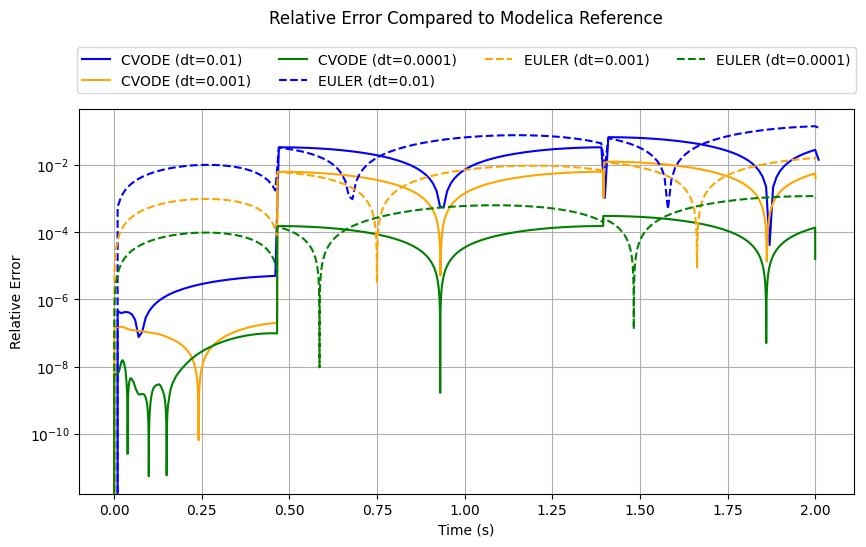

In [10]:
errors = {}
for solver_name, solver_results in fmu_results.items():
    errors[solver_name] = {}
    for dt, results in solver_results.items():
        t_vals = results['theta']['time']
        theta_vals = results['theta']['values']
        ref_interp = np.interp(t_vals, t_ref, theta_ref)
        error = np.abs(theta_vals - ref_interp) / np.max(np.abs(ref_interp))
        errors[solver_name][dt] = error

plt.figure(figsize=(10, 5))
for solver_name, solver_errors in errors.items():
    linestyle = linestyles[solver_name]
    for dt, error in solver_errors.items():
        color = colors[float(dt)]
        t_vals = fmu_results[solver_name][dt]['theta']['time']
        plt.semilogy(t_vals, error, label=f'{solver_name.upper()} (dt={dt})', linestyle=linestyle, color=color)
plt.xlabel('Time (s)')
plt.ylabel('Relative Error')
plt.title('Relative Error Compared to Modelica Reference', y=1.2)
plt.legend(loc='center', bbox_to_anchor=(0.5, 1.1), ncol=4)
plt.grid()
plt.show()

## Conclusion

This tutorial showed that FMUs containing Modelica state events are sensitive to macro communication step size when used in co-simulation.

A smaller `dt` is typically required to detect impact events with high timing accuracy if no additional localization strategy is used.

In the following tutorials, we extend the `FMUComponent` workflow in `syssimx` with rollback and event-handling capabilities to localize events more accurately without relying only on globally small macro steps.
